# Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score

# Introdução ao Dataset

In [2]:
dataset = pd.read_csv("dataset2025.csv")
df = pd.DataFrame(dataset)

df

,Year,quarter,Bene_Geo_Desc,Bene_Mdcd_Mdcr_Enrl_Stus,Bene_Race_Desc,Bene_Sex_Desc,Bene_Mdcr_Entlmt_Stus,Bene_Age_Desc,Bene_RUCA_Desc,Total_Bene_TH_Elig,Total_PartB_Enrl,Total_Bene_Telehealth,Pct_Telehealth
0,2020,Overall,National,All,All,All,All,All,All,30946785.0,3.224489e+07,14826919.0,0.4791
1,2020,Overall,National,All,All,All,All,All,Rural,7182616.0,7.493527e+06,2859483.0,0.3981
2,2020,Overall,National,All,All,All,All,All,Urban,23699049.0,2.463142e+07,11945312.0,0.5040
3,2020,Overall,National,All,All,All,All,All,Unknown,NaN,NaN,NaN,NaN
4,2020,Overall,National,All,All,All,All,0-64,All,4088345.0,4.291403e+06,2322324.0,0.5680
...,...,...,...,...,...,...,...,...,...,...,...,...,...
31299,2025,1,Virginia,All,All,All,All,All,Unknown,NaN,NaN,NaN,NaN
31300,2025,1,Washington,All,All,All,All,All,Unknown,NaN,NaN,NaN,NaN
31301,2025,1,West Virginia,All,All,All,All,All,Unknown,NaN,NaN,NaN,NaN
31302,2025,1,Wisconsin,All,All,All,All,All,Unknown,NaN,NaN,NaN,NaN


In [3]:
# Criar coluna binária para target
limiar = df["Pct_Telehealth"].quantile(0.75)

# Se for maior ou igual ao limiar de 75% --> faz parte dos 25%
df["Telehealth_Class"] = df["Pct_Telehealth"].apply(lambda x: 1 if x >= limiar else 0)

df.head()

,Year,quarter,Bene_Geo_Desc,Bene_Mdcd_Mdcr_Enrl_Stus,Bene_Race_Desc,Bene_Sex_Desc,Bene_Mdcr_Entlmt_Stus,Bene_Age_Desc,Bene_RUCA_Desc,Total_Bene_TH_Elig,Total_PartB_Enrl,Total_Bene_Telehealth,Pct_Telehealth,Telehealth_Class
0,2020,Overall,National,All,All,All,All,All,All,30946785.0,3.224489e+07,14826919.0,0.4791,1
1,2020,Overall,National,All,All,All,All,All,Rural,7182616.0,7.493527e+06,2859483.0,0.3981,1
2,2020,Overall,National,All,All,All,All,All,Urban,23699049.0,2.463142e+07,11945312.0,0.5040,1
3,2020,Overall,National,All,All,All,All,All,Unknown,NaN,NaN,NaN,NaN,0
4,2020,Overall,National,All,All,All,All,0-64,All,4088345.0,4.291403e+06,2322324.0,0.5680,1


## Identificação das Variáveis:

- Year: Ano de referência dos dados de reivindicações do Medicare Part B — Categórica
- Quarter: Trimestre do ano (1 = Jan-Mar, 2 = Abr-Jun, etc.) — Categórica
- Bene_Geo_Desc: Estado ou território de residência do beneficiário — Categórica
- Bene_Mdcd_Mdcr_Enrl_Stus: Status de elegibilidade (Medicare apenas ou Medicare + Medicaid) — Categórica
- Bene_Race_Desc: Raça/Etnia do beneficiário — Categórica
- Bene_Sex_Desc: Sexo do beneficiário — Categórica
- Bene_Mdcr_Entlmt_Stus: Tipo de direito ao Medicare (Idoso, Deficiente, ESRD) — Categórica
- Bene_Age_Desc: Faixa etária do beneficiário — Categórica
- Bene_RUCA_Desc: Status rural ou urbano baseado no CEP — Categórica
- Total_Bene_TH_Elig: Número de beneficiários elegíveis para serviços de telemedicina — Numérica
- Total_PartB_Enrl: Número total de beneficiários com plano Medicare Part B — Numérica
- Total_Bene_Telehealth: Número de beneficiários que utilizaram serviços de telemedicina — Numérica
- Pct_Telehealth: Percentual de usuários que utilizaram telemedicina entre os elegíveis — Numérica
- Telehealth_Class: Classe binária criada: 1 = alta adoção, 0 = baixa adoção — Categórica


# Pré-Processamento

In [4]:
# Ver se precisa de normalização e tratamento de valores nulos
df.describe()

,Year,Total_Bene_TH_Elig,Total_PartB_Enrl,Total_Bene_Telehealth,Pct_Telehealth,Telehealth_Class
count,31304.000000,2.799000e+04,2.799000e+04,2.792900e+04,27927.000000,31304.000000
mean,2022.115385,5.040508e+05,6.291266e+05,1.068925e+05,0.211861,0.223071
std,1.501995,2.074896e+06,2.566128e+06,4.950447e+05,0.131145,0.416312
min,2020.000000,1.100000e+01,1.666667e+01,0.000000e+00,0.000000,0.000000
25%,2021.000000,1.752575e+04,2.255375e+04,3.210000e+03,0.113700,0.000000
50%,2022.000000,7.805600e+04,1.004595e+05,1.288600e+04,0.177600,0.000000
75%,2023.000000,2.600962e+05,3.331074e+05,4.553200e+04,0.278900,0.000000
max,2025.000000,3.094678e+07,3.234423e+07,1.482692e+07,0.820200,1.000000


In [5]:
df.isnull().sum()

Year                           0
quarter                        0
Bene_Geo_Desc                  0
Bene_Mdcd_Mdcr_Enrl_Stus       0
Bene_Race_Desc                 0
Bene_Sex_Desc                  0
Bene_Mdcr_Entlmt_Stus          0
Bene_Age_Desc                  0
Bene_RUCA_Desc                 0
Total_Bene_TH_Elig          3314
Total_PartB_Enrl            3314
Total_Bene_Telehealth       3375
Pct_Telehealth              3377
Telehealth_Class               0
dtype: int64

As escalas são muito diferentes, precisaremos normalizar as variáveis numéricas e iremos aproveitar e transformar as categóricas em numéricas também.

Considerando que o dataset possui mais de 30 mil linhas, a quantidade de valores nulos não é tão grande e, portanto, não será prejudicial se droparmos 

In [6]:
# Dropando nulos
df_clean = df.dropna().copy()
df_clean.isnull().sum()

Year                        0
quarter                     0
Bene_Geo_Desc               0
Bene_Mdcd_Mdcr_Enrl_Stus    0
Bene_Race_Desc              0
Bene_Sex_Desc               0
Bene_Mdcr_Entlmt_Stus       0
Bene_Age_Desc               0
Bene_RUCA_Desc              0
Total_Bene_TH_Elig          0
Total_PartB_Enrl            0
Total_Bene_Telehealth       0
Pct_Telehealth              0
Telehealth_Class            0
dtype: int64

In [7]:
# Definir X (features) e y (target)
X = df_clean.drop(columns=["Telehealth_Class", "Pct_Telehealth"])  # removendo target e pct_telehealth
y = df_clean["Telehealth_Class"]

# Definir colunas numéricas e categóricas
num_cols = [
    "Total_Bene_TH_Elig",
    "Total_PartB_Enrl",
    "Total_Bene_Telehealth"
]

cat_cols = [
    "Year",
    "quarter",
    "Bene_Geo_Desc",
    "Bene_Mdcd_Mdcr_Enrl_Stus",
    "Bene_Race_Desc",
    "Bene_Sex_Desc",
    "Bene_Mdcr_Entlmt_Stus",
    "Bene_Age_Desc",
    "Bene_RUCA_Desc"
]

# Normalização e codificação (transformar colunas categóricas em numéricas) --> será usado em um pipeline futuramente
preprocessador = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
    ]
)

# Análise Exploratória

## Análise de Coeficientes

In [8]:
# Divisão em treino e teste (20% para teste)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42
)

# Normalização e codificação (transformar colunas categóricas em numéricas) --> será usado em um pipeline futuramente
preprocessador = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
    ]
)

# pré-processamento
pipe = Pipeline(steps=[
    ("preprocessador", preprocessador),
    ("classifier", LogisticRegression(max_iter=1000, random_state=42))
])

# Treinar
pipe.fit(X_train, y_train)

# Predições
y_pred = pipe.predict(X_test)
y_proba = pipe.predict_proba(X_test)[:,1]

# Avaliação de eficiência da regressão
print("Accuracy:", accuracy_score(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_proba))
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=["Baixa Adoção", "Alta Adoção"]))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred)) # TP (True Positive), FP (False Positive), FN (False Negative), TN (True Negative). 

# Importância dos coeficientes
coef = pd.Series(
    pipe.named_steps["classifier"].coef_[0],
    index=pipe.named_steps["preprocessador"].get_feature_names_out()
)

print("\nTop 10 features by magnitude:")
print(coef.abs().sort_values(ascending=False).head(10))

Accuracy: 0.9215896885069818
ROC AUC: 0.9737492936215499

Classification Report:
              precision    recall  f1-score   support

Baixa Adoção       0.94      0.96      0.95      4189
 Alta Adoção       0.87      0.80      0.84      1397

    accuracy                           0.92      5586
   macro avg       0.90      0.88      0.89      5586
weighted avg       0.92      0.92      0.92      5586


Confusion Matrix:
[[4025  164]
 [ 274 1123]]

Top 10 features by magnitude:
num__Total_Bene_Telehealth          16.698339
num__Total_Bene_TH_Elig             15.838868
cat__Bene_Geo_Desc_California        3.928185
num__Total_PartB_Enrl                3.482175
cat__Year_2020                       3.376386
cat__Bene_Age_Desc_0-64              2.992348
cat__Bene_Geo_Desc_North Dakota      2.981148
cat__quarter_Overall                 2.757799
cat__Bene_Geo_Desc_Massachusetts     2.721396
cat__Bene_Geo_Desc_Hawaii            2.660735
dtype: float64


Na matriz de confusão tivemos 4025 True Positive, 164 False Positive, 274 False Negative e 1123 True Negative.

O modelo é mais preciso para classificar a Baixa Adoção (classe majoritária) do que a Alta Adoção

## Correlação

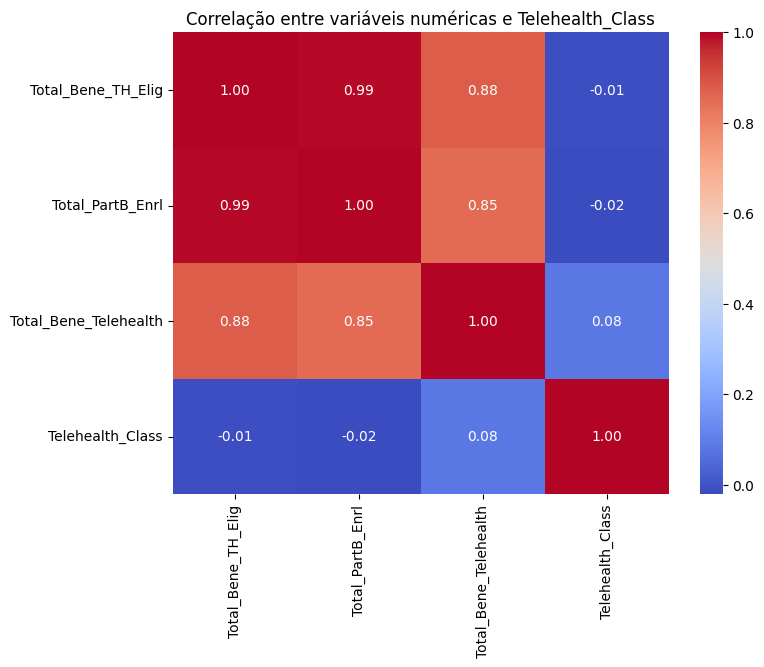

In [9]:
# Apenas colunas numéricas e target
df_corr = df_clean[[
    "Total_Bene_TH_Elig",
    "Total_PartB_Enrl",
    "Total_Bene_Telehealth",
    "Telehealth_Class"
]]

# Calcular correlação
corr = df_corr.corr()

# Plotar heatmap
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlação entre variáveis numéricas e Telehealth_Class")
plt.show()


Sinceramente não entendi muito, a correlação com o target é minúscula porém essas variáveis foram consideradas de grande relevância para a regressão...

A única coisa que consegui pensar é que a correlação 1x1 não possui grande significância. Mas, ao juntar as variáveis elas se tornam importantes para a predição.<br/>
Embora a baixa correlação das variáveis com o target, elas possuem ENORME correlação entre elas, indicando multicolinearidade. Iremos retirar uma delas e observar a reação do modelo

In [10]:
y = df_clean["Telehealth_Class"]
# Lista ajustada removendo Total_Bene_TH_Elig (colinear com Total_PartB_Enrl)
X_novo = df_clean.drop(columns=["Telehealth_Class", "Pct_Telehealth", "Total_Bene_TH_Elig"])

# Definir colunas numéricas (sem Total_Bene_TH_Elig)
num_cols_novo = ["Total_PartB_Enrl", "Total_Bene_Telehealth"]

# Definir colunas categóricas
cat_cols = [
    "Year", "quarter", "Bene_Geo_Desc", "Bene_Mdcd_Mdcr_Enrl_Stus",
    "Bene_Race_Desc", "Bene_Sex_Desc", "Bene_Mdcr_Entlmt_Stus",
    "Bene_Age_Desc", "Bene_RUCA_Desc"
]

# Divisão em treino e teste (20% para teste)
X_train, X_test, y_train, y_test = train_test_split(
    X_novo, y, test_size=0.20, stratify=y, random_state=42
)

# Pré-processador atualizado
preprocessador = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols_novo),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
    ]
)

# Pipeline atualizado
pipe = Pipeline(steps=[
    ("preprocessador", preprocessador),
    ("classifier", LogisticRegression(max_iter=1000, random_state=42))
])

# Treinar
pipe.fit(X_train, y_train)

# Predições
y_pred = pipe.predict(X_test)
y_proba = pipe.predict_proba(X_test)[:,1]

# Avaliação
print("Accuracy:", accuracy_score(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_proba))
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=["Baixa Adoção", "Alta Adoção"]))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# Importância dos coeficientes
coef = pd.Series(
    pipe.named_steps["classifier"].coef_[0],
    index=pipe.named_steps["preprocessador"].get_feature_names_out()
)

print("\nTop 10 features by magnitude:")
print(coef.abs().sort_values(ascending=False).head(10))


Accuracy: 0.9144289294665234
ROC AUC: 0.9672558237453548

Classification Report:
              precision    recall  f1-score   support

Baixa Adoção       0.93      0.96      0.94      4189
 Alta Adoção       0.86      0.79      0.82      1397

    accuracy                           0.91      5586
   macro avg       0.89      0.87      0.88      5586
weighted avg       0.91      0.91      0.91      5586


Confusion Matrix:
[[4007  182]
 [ 296 1101]]

Top 10 features by magnitude:
num__Total_PartB_Enrl                  10.138308
num__Total_Bene_Telehealth              8.218362
cat__Bene_Geo_Desc_California           4.405132
cat__Year_2020                          3.550679
cat__Bene_Geo_Desc_North Dakota         3.239569
cat__Bene_Age_Desc_0-64                 3.130629
cat__Bene_Geo_Desc_Massachusetts        2.875106
cat__quarter_Overall                    2.768813
cat__Bene_Geo_Desc_Hawaii               2.747452
cat__Bene_Mdcr_Entlmt_Stus_Disabled     2.368795
dtype: float64


In [11]:
y = df_clean["Telehealth_Class"]
# Lista ajustada removendo Total_Bene_TH_Elig e Total_PartB_Enrl
X_novo2 = df_clean.drop(columns=["Telehealth_Class", "Pct_Telehealth", "Total_Bene_TH_Elig", "Total_PartB_Enrl"])

# Definir colunas numéricas
num_cols_novo2 = ["Total_Bene_Telehealth"]

# Definir colunas categóricas
cat_cols = [
    "Year", "quarter", "Bene_Geo_Desc", "Bene_Mdcd_Mdcr_Enrl_Stus",
    "Bene_Race_Desc", "Bene_Sex_Desc", "Bene_Mdcr_Entlmt_Stus",
    "Bene_Age_Desc", "Bene_RUCA_Desc"
]

# Divisão em treino e teste (20% para teste)
X_train, X_test, y_train, y_test = train_test_split(
    X_novo2, y, test_size=0.20, stratify=y, random_state=42
)

# Pré-processador atualizado
preprocessador = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols_novo2),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
    ]
)

# Pipeline atualizado
pipe = Pipeline(steps=[
    ("preprocessador", preprocessador),
    ("classifier", LogisticRegression(max_iter=1000, random_state=42))
])

# Treinar
pipe.fit(X_train, y_train)

# Predições
y_pred = pipe.predict(X_test)
y_proba = pipe.predict_proba(X_test)[:,1]

# Avaliação
print("Accuracy:", accuracy_score(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_proba))
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=["Baixa Adoção", "Alta Adoção"]))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# Importância dos coeficientes
coef = pd.Series(
    pipe.named_steps["classifier"].coef_[0],
    index=pipe.named_steps["preprocessador"].get_feature_names_out()
)

print("\nTop 10 features by magnitude:")
print(coef.abs().sort_values(ascending=False).head(10))


Accuracy: 0.905656999641962
ROC AUC: 0.9592731278172901

Classification Report:
              precision    recall  f1-score   support

Baixa Adoção       0.92      0.95      0.94      4189
 Alta Adoção       0.84      0.77      0.80      1397

    accuracy                           0.91      5586
   macro avg       0.88      0.86      0.87      5586
weighted avg       0.90      0.91      0.90      5586


Confusion Matrix:
[[3987  202]
 [ 325 1072]]

Top 10 features by magnitude:
cat__Bene_Geo_Desc_California          4.132388
cat__Year_2020                         3.764221
cat__Bene_Age_Desc_0-64                3.552249
cat__quarter_Overall                   3.333849
cat__Bene_Geo_Desc_North Dakota        3.333687
cat__Bene_Geo_Desc_Massachusetts       3.194896
cat__Bene_Geo_Desc_Hawaii              3.034046
cat__Bene_Mdcr_Entlmt_Stus_Disabled    2.781043
cat__Bene_Geo_Desc_Tennessee           2.481093
cat__Bene_Geo_Desc_Nebraska            2.464273
dtype: float64


Quanto mais retira as variáveis, menos preciso fica. No último teste, aquelas variáveis nem apareceram...<br/>
Ou seja, isso ficou mais confuso :). Acredito que não seja uma colinearidade, mas sim um conjunto de variáveis que ajudam no modelo?

De qualquer forma, vamos confirmar os coeficientes usados após os modelos L1 e L2 para ter certeza

## Gráfico Região

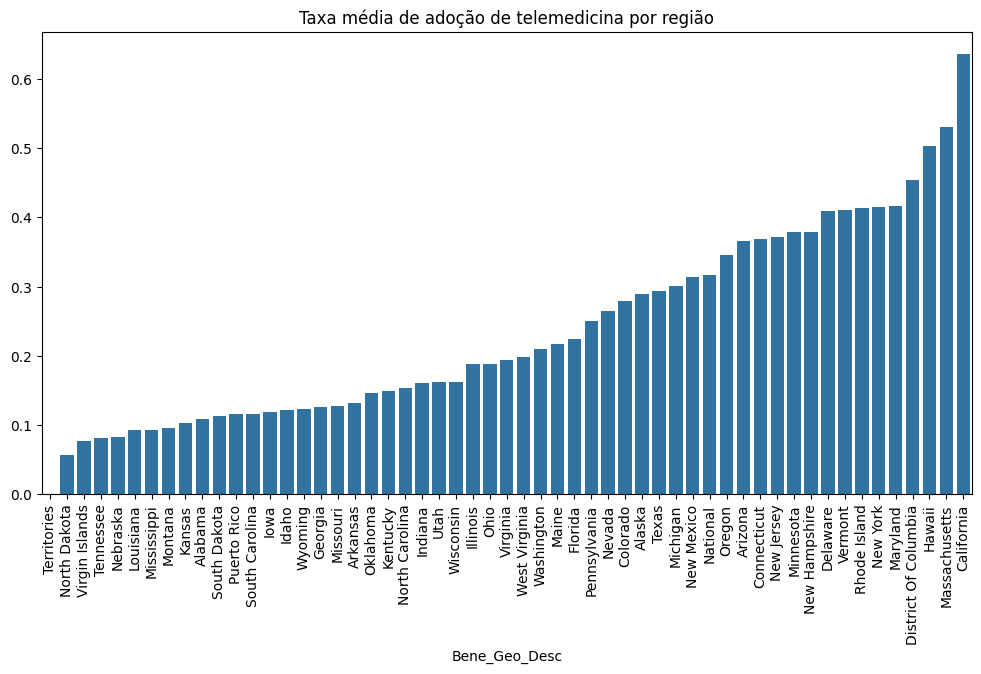

In [12]:
# Telemedicina por região
region_usage = df_clean.groupby("Bene_Geo_Desc")["Telehealth_Class"].mean().sort_values()
plt.figure(figsize=(12,6))
sns.barplot(x=region_usage.index, y=region_usage.values)
plt.xticks(rotation=90)
plt.title("Taxa média de adoção de telemedicina por região")
plt.show()


O gráfico sugere desigualdade geográfica no acesso à saúde digital:
- Massachusetts, Califórnia e Distrito de Columbia lideram com as maiores taxas médias de adoção.
- Territórios, North Dakota e West Virginia estão entre os menores índices.
- Estados mais urbanizados e com maior infraestrutura digital tendem a adotar mais --> Territórios e estados rurais enfrentam barreiras como acesso à internet, menor densidade populacional e menor familiaridade tecnológica. Estados com sistemas de saúde mais integrados e políticas pró-tecnologia (cidades grandes/áreas urbanas) facilitam o uso da telemedicina.

# Validação Cruzada

In [13]:
# Preprocessador e pipe do x_novo (acurácia não caiu tanto e apareceram outros coeficientes importantes para a região)
preprocessador = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols_novo),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
    ]
)

# Pipeline atualizado
pipe = Pipeline(steps=[
    ("preprocessador", preprocessador),
    ("classifier", LogisticRegression(max_iter=1000, random_state=42))
])

# Separando todos os modelos conhecidos para comparação
models = {
    "Logistic L1": LogisticRegression(penalty="l1", solver="liblinear", max_iter=1000),
    "Logistic L2": LogisticRegression(penalty="l2", solver="saga", max_iter=1000),
    "SVM RBF": SVC(kernel="rbf", C=1, gamma="scale"),
    "KNN": KNeighborsClassifier(n_neighbors=5)
}

# Validação cruzada X --> sem nenhuma variável retirada
for name, model in models.items():
    pipe = Pipeline(steps=[("preprocessador", preprocessador),
                           ("classifier", model)])
    scores = cross_val_score(pipe, X_novo, y, cv=5, scoring="accuracy")
    print(f"{name} - Acurácia média: {scores.mean():.3f}")

Logistic L1 - Acurácia média: 0.776
Logistic L2 - Acurácia média: 0.773
SVM RBF - Acurácia média: 0.730
KNN - Acurácia média: 0.776


Escolhemos o modelo retirando apenas uma variável da colinearidade, pois a acurácia não caiu tanto e apareceram outras variáveis importantes para a análise dos coeficientes do L1 e L2 posteriormente

# Implementação do Modelo

## L1 (Lasso)

In [15]:
# Lista ajustada removendo Total_Bene_TH_Elig (colinear com Total_PartB_Enrl)
X_novo = df_clean.drop(columns=["Telehealth_Class", "Pct_Telehealth", "Total_Bene_TH_Elig"])

# Definir colunas numéricas (sem Total_Bene_TH_Elig)
num_cols_novo = ["Total_PartB_Enrl", "Total_Bene_Telehealth"]

# Divisão em treino e teste (20% para teste)
X_train, X_test, y_train, y_test = train_test_split(
    X_novo, y, test_size=0.20, stratify=y, random_state=42
)

# Pré-processador atualizado
preprocessador = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols_novo),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
    ]
)

# Pipeline para o L1
pipe_l1 = Pipeline(steps=[
    ("preprocessador", preprocessador),
    ("classifier", LogisticRegression(penalty="l1", solver="liblinear", max_iter=1000))
])

# GridSearch para encontrar melhor C
param_grid_l1 = {"classifier__C": [0.01, 0.1, 1, 10]}
best_l1 = GridSearchCV(pipe_l1, param_grid_l1, scoring="roc_auc", cv=5, n_jobs=-1, refit=True)
best_l1.fit(X_train, y_train)

# Previsões no teste
y_pred_l1 = best_l1.predict(X_test)
y_proba_l1 = best_l1.predict_proba(X_test)[:,1]

# Print dos Resultados
print("~~~ Regressão Logística L1 (Lasso) ~~~")
print(f"Melhor C: {best_l1.best_params_['classifier__C']}")
print(f"CV AUC: {best_l1.best_score_:.4f}")
print(f"Test AUC: {roc_auc_score(y_test, y_proba_l1):.4f}")
print(f"Test Accuracy: {accuracy_score(y_test, y_pred_l1):.4f}")

# Verificando se houveram coeficientes zerados no L1
coef = best_l1.best_estimator_.named_steps["classifier"].coef_[0]
non_zero = np.sum(coef != 0)
total = coef.shape[0]
print(f"Número de coeficientes não nulos: {non_zero}/{total}")

~~~ Regressão Logística L1 (Lasso) ~~~
Melhor C: 10
CV AUC: 0.9675
Test AUC: 0.9704
Test Accuracy: 0.9193
Número de coeficientes não nulos: 92/92


## L2 (Ridge)

In [16]:
# Lista ajustada removendo Total_Bene_TH_Elig (colinear com Total_PartB_Enrl)
X_novo = df_clean.drop(columns=["Telehealth_Class", "Pct_Telehealth", "Total_Bene_TH_Elig"])

# Definir colunas numéricas (sem Total_Bene_TH_Elig)
num_cols_novo = ["Total_PartB_Enrl", "Total_Bene_Telehealth"]

# Divisão em treino e teste (20% para teste)
X_train, X_test, y_train, y_test = train_test_split(
    X_novo, y, test_size=0.20, stratify=y, random_state=42
)

# Pré-processador atualizado
preprocessador = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols_novo),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
    ]
)

# Pipeline para o L2
pipe_l2 = Pipeline(steps=[
    ("preprocessador", preprocessador),
    ("classifier", LogisticRegression(penalty="l2", solver="saga", max_iter=3000))
])

# GridSearch para encontrar melhor C
param_grid_l2 = {"classifier__C": [0.01, 0.1, 1, 10]}
best_l2 = GridSearchCV(pipe_l2, param_grid_l2, scoring="roc_auc", cv=5, n_jobs=-1, refit=True)
best_l2.fit(X_train, y_train)

# Previsões no teste
y_pred_l2 = best_l2.predict(X_test)
y_proba_l2 = best_l2.predict_proba(X_test)[:,1]

# Print dos Resultados
print("~~~ Regressão Logística L2 (Ridge) ~~~")
print(f"Melhor C: {best_l2.best_params_['classifier__C']}")
print(f"CV AUC: {best_l2.best_score_:.4f}")
print(f"Test AUC: {roc_auc_score(y_test, y_proba_l2):.4f}")
print(f"Test Accuracy: {accuracy_score(y_test, y_pred_l2):.4f}")

# Verificando se houveram coeficientes zerados no L2
coef = best_l2.best_estimator_.named_steps["classifier"].coef_[0]
non_zero = np.sum(coef != 0)
total = coef.shape[0]
print(f"Número de coeficientes não nulos: {non_zero}/{total}")

~~~ Regressão Logística L2 (Ridge) ~~~
Melhor C: 10
CV AUC: 0.9667
Test AUC: 0.9694
Test Accuracy: 0.9169
Número de coeficientes não nulos: 92/92


# Finalização Coeficientes

                        feature    coef_L1    coef_L2     abs_L1     abs_L2
0                     Year_2020 -20.415092 -16.701938  20.415092  16.701938
1                     Year_2021  16.437712  13.459442  16.437712  13.459442
17    Bene_Geo_Desc_Connecticut   5.164357   5.015773   5.164357   5.015773
2                     Year_2022   2.486666   3.552217   2.486666   3.552217
48       Bene_Geo_Desc_Oklahoma  -3.504152  -3.469543   3.504152   3.469543
58           Bene_Geo_Desc_Utah  -5.996808  -3.464069   5.996808   3.464069
34      Bene_Geo_Desc_Minnesota   3.038114   3.057685   3.038114   3.057685
84          Bene_Age_Desc_75-84   3.287996   3.038513   3.287996   3.038513
24       Bene_Geo_Desc_Illinois   2.836570   2.882946   2.836570   2.882946
12         Bene_Geo_Desc_Alaska   2.058283   2.590206   2.058283   2.590206
41  Bene_Geo_Desc_New Hampshire  -2.428382  -2.416973   2.428382   2.416973
57          Bene_Geo_Desc_Texas  -2.409190  -2.399957   2.409190   2.399957
46   Bene_Ge

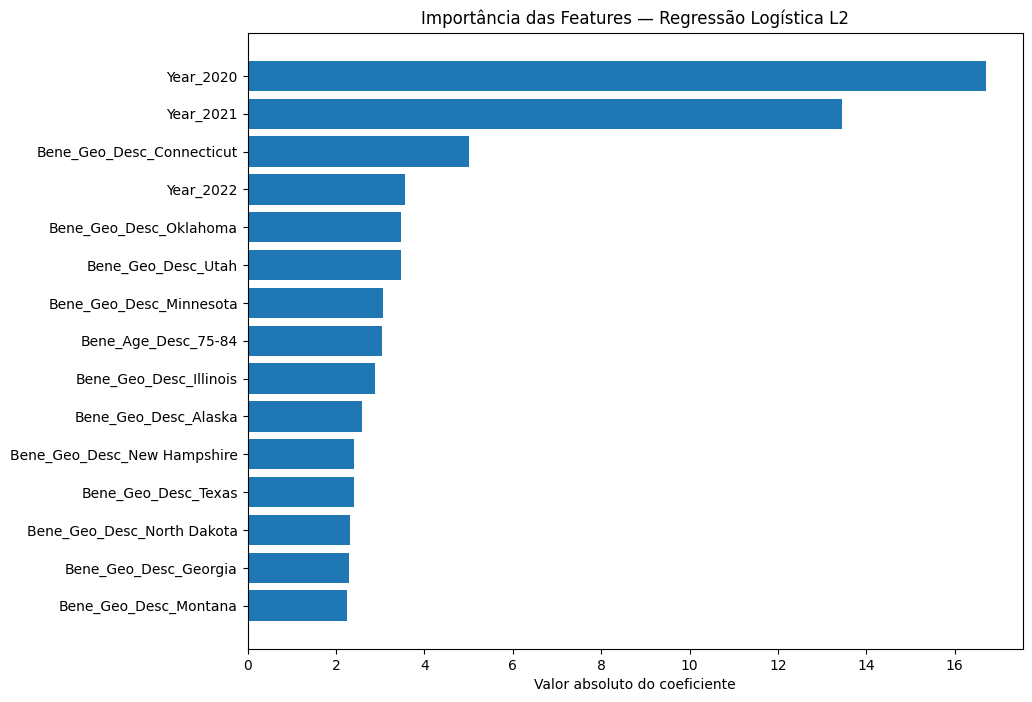

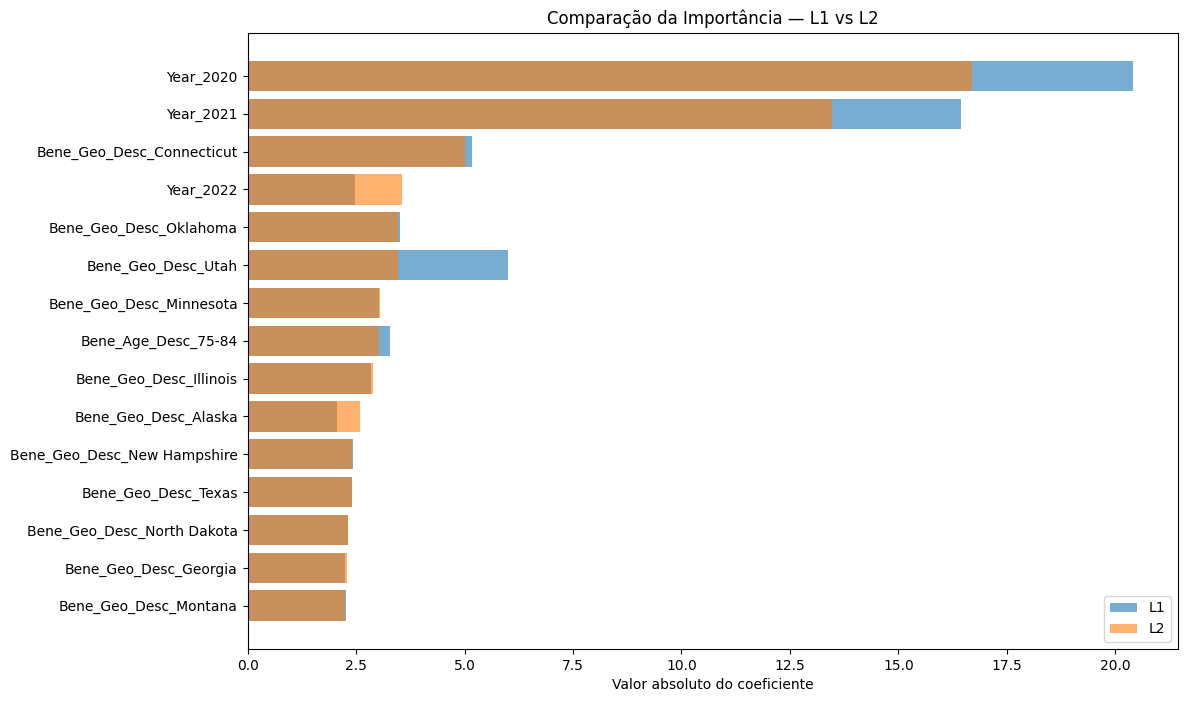

In [17]:
# Recuperar o OneHotEncoder já ajustado dentro do pipeline
ohe = best_l2.best_estimator_.named_steps['preprocessador'].named_transformers_['cat']
encoded_cat_cols = ohe.get_feature_names_out()

# Juntar nomes das features categóricas e numéricas
# Use num_cols_novo que foi usado nos pipelines
all_feature_names = list(encoded_cat_cols) + num_cols_novo

# Coeficientes do modelo L1 e L2
coef_l1 = best_l1.best_estimator_.named_steps['classifier'].coef_[0]
coef_l2 = best_l2.best_estimator_.named_steps['classifier'].coef_[0]

# DataFrame com os coeficientes
coef_df = pd.DataFrame({
    "feature": all_feature_names,
    "coef_L1": coef_l1,
    "coef_L2": coef_l2,
    "abs_L1": np.abs(coef_l1),
    "abs_L2": np.abs(coef_l2)
})

# Ordenar pelas features mais importantes no L2
coef_df_sorted = coef_df.sort_values("abs_L2", ascending=False)
print(coef_df_sorted.head(15))

# Plot — Importância das Features L2
plt.figure(figsize=(10, 8))
top_features = coef_df_sorted.head(15)
plt.barh(top_features['feature'], top_features['abs_L2'])
plt.gca().invert_yaxis()
plt.title("Importância das Features — Regressão Logística L2")
plt.xlabel("Valor absoluto do coeficiente")
plt.show()

# Plot — Comparação L1 vs L2
plt.figure(figsize=(12, 8))
top_features = coef_df_sorted.head(15)
plt.barh(top_features["feature"], top_features["abs_L1"], alpha=0.6, label="L1")
plt.barh(top_features["feature"], top_features["abs_L2"], alpha=0.6, label="L2")
plt.gca().invert_yaxis()
plt.title("Comparação da Importância — L1 vs L2")
plt.xlabel("Valor absoluto do coeficiente")
plt.legend()
plt.show()


# Conclusão

- O modelo L1 (Lasso) foi o mais ideal nessa situação
- Nenhum coeficiente foi nulo ao retirar uma das variáveis com colinearidade
- Há muitos coeficientes geográficos importantes para a classificação de Alta Adoção/Baixa Adoção da telemedina, indicando grande desigualdade de adoção por faixa demográfica
- A análise de importância das features revelou forte influência de variáveis temporais, como o ano de 2020, reforçando o impacto da pandemia na adoção da telemedicina.